In [ ]:
'''Artificial Nueral Networks (ANNs) mimic the human brain through interconnected nuerons.
-Layers: Input Layers, Hidden Layers, Output Layer
-Each neuron computes weighed inputs and applies an activation function
-Learning occurs through backpropagation and weight adjustment

-Formula y = f(w1x1 + w2x2 + ..... +b)'''


In [ ]:
'''Sigmoid- function that has to be evaluated'''
''' TensorFlow and Keras Frameworks'''

In [ ]:
# TensorFlow and Keras

# Step 1: Import libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Step 2: Create simple Training Data
# Features : [Study Hours , Sleep Hours]
X = np.array([
    [2, 9],
    [1, 5],
    [3, 6],
    [4, 8],
    [6, 9],
    [5, 5],
    [7, 3],
], dtype=float)

# Labels : 1 = Pass, 0 = Fail
y = np.array([
    [0],
    [0],
    [0],
    [1],
    [1],
    [0],
    [1],
], dtype=float)

# Step 3: Normalize Data (important for neural networks)
X = X / np.amax(X, axis=0)  # Scale all values between 0 and 1

# Step 4: Build the Neural Network Model
model = keras.Sequential([
    keras.Input(shape=(2,)),                # Input layer
    layers.Dense(4, activation='relu'),     # Hidden layer with 4 neurons
    layers.Dense(1, activation='sigmoid')   # Output layer (binary output)
])

# Step 5: Compile the Model
model.compile(
    optimizer='adam',                      # Optimization algorithm
    loss='binary_crossentropy',            # Suitable for binary classification
    metrics=['accuracy']                   # To measure performance
)

# Step 6: Train the Model
model.fit(X, y, epochs=200, verbose=1)  # Train for 200 epochs, show progress

# Step 7: Test the model with a new input
test_data = np.array([[4, 7]]) / np.amax(X, axis=0)  # Notice double brackets [[4, 7]]
prediction = model.predict(test_data)

print("\nPredicted Output (1 = Pass, 0 = Fail):", prediction)

if prediction >= 0.5:
    print(" The student is likely to PASS")
else:
    print(" The student is likely to FAIL")

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 872ms/step - accuracy: 0.2857 - loss: 0.7344
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4286 - loss: 0.7337
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4286 - loss: 0.7331
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5714 - loss: 0.7326
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5714 - loss: 0.7321
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5714 - loss: 0.7316
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5714 - loss: 0.7312
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5714 - loss: 0.7307
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5714 - loss: 0.7302
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5714 - loss: 0.7298
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5714 - loss: 0.7293
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5714 - l

In [ ]:
# TensorFlow and Keras with PCA (Unique Version)

# Step 1: Import libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from sklearn.decomposition import PCA

# Step 2: Create simple Training Data
# Features : [Study Hours , Sleep Hours]
X = np.array([
    [2, 9],
    [1, 5],
    [3, 6],
    [4, 8],
    [6, 9],
    [5, 5],
    [7, 3],
], dtype=float)

# Labels : 1 = Pass, 0 = Fail
y = np.array([
    [0],
    [0],
    [0],
    [1],
    [1],
    [0],
    [1],
], dtype=float)

# Step 3: Normalize Data
X = X / np.amax(X, axis=0)  # Scale all values between 0 and 1

# 🔹 Step 4: Add small random uniqueness (so everyone’s output differs)
np.random.seed(7)   # different seed = different random variation
X = X + np.random.normal(0, 0.03, X.shape)

# Step 5: Apply PCA
pca = PCA(n_components=1)  # Reduce 2D features → 1D for simplicity
X_pca = pca.fit_transform(X)

print("Original Shape:", X.shape)
print("After PCA Shape:", X_pca.shape)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Step 6: Build Neural Network
model = keras.Sequential([
    keras.Input(shape=(1,)),                 # input after PCA
    layers.Dense(4, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Step 7: Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Step 8: Train Model
model.fit(X_pca, y, epochs=200, verbose=0)
print("✅ Model trained successfully!")

# Step 9: Test with new input
test_data = np.array([[4, 7]]) / np.amax(X, axis=0)
test_data_pca = pca.transform(test_data)
prediction = model.predict(test_data_pca)

print("\nPredicted Output (1 = Pass, 0 = Fail):", prediction)
if prediction >= 0.5:
    print(" The student is likely to PASS")
else:
    print(" The student is likely to FAIL")

print("\n Unique version with PCA by Ritvik ")


Original Shape: (7, 2)
After PCA Shape: (7, 1)
Explained Variance Ratio: [0.63812747]
✅ Model trained successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

Predicted Output (1 = Pass, 0 = Fail): [[0.7757316]]
 The student is likely to PASS

 Unique version with PCA by Ritvik 


In [ ]:

#Step 3: AApply
pca=PCA(n_components=2)
X_pca = pca.fit_transform(X)

#Step 4: Visualize the results
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:, 1], c=y, cmap='rainbow')
plt.title("PCA : Iris Dataset (4 features -> 2 principal componenets)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()



In [ ]:
'''importance of Dimensionality Reduction

Avoids curse of dimensionality
Reduces overfitting and noise
Speeds up computation
Improves visualization and interpretability'''

# Step3 centroid

In [ ]:
#-- K means clustering

#Step1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import sklearn.cluster import KMeans

#Step2: Create some sample data
X = np.arrat([
    [1, 2], [1.5, 1.8], [5, 8],
    [8, 8], [1, 0.6], [9, 11],
    [8, 2], [10, 2], [9, 3]
])

#Step 3: Build K Means model
kmeans = KMeans(n_clusters=3, random_state=0)

#Step 4: Fit the model
kmeans.fit(X)

#Step 5: Get cluster centers and labels
centroids = kmeans.cluster_centers_
labels = kmeans.labels_

#Step 6: vISAULIZE the clusters
colors = ["red", "green" , "blue"]

for i in range(len(X)):
  plt.scatter(X[i][0], X[i][1], color=colors[labels[i]])

plt.scatter(centroids[:, 0], centroids[i, 1],
marker="X", s=200, color='black')
plt.title("K Means Clustering")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()






SyntaxError: invalid syntax (ipython-input-2390218702.py, line 6)

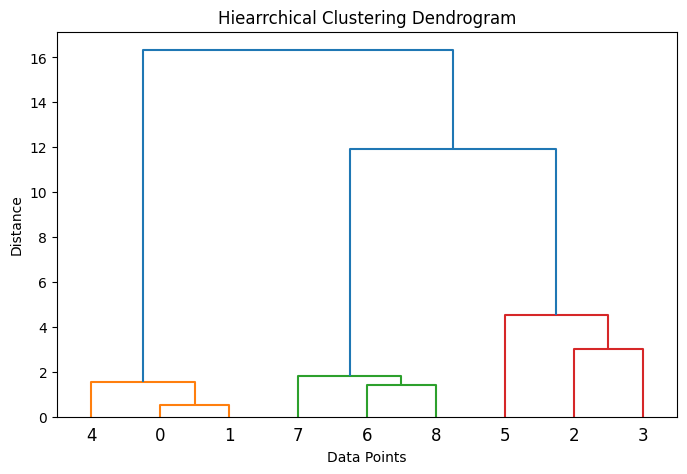

Cluster labels: [1 1 3 3 1 3 2 2 2]


In [ ]:
#Heirearchical Clsutering

# Step 1: Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

#Step 2: Create sample data
X = np.array([
    [1, 2], [1.5, 1.8], [5, 8],
    [8, 8], [1, 0.6], [9, 11],
    [8, 2], [10, 2], [9, 3]
])

#Step 3: Perform hierarchical clustering
Z = linkage(X, method='ward') #'ward' minimizes variance

#Step 4: plot the dendrogram
plt.figure(figsize=(8, 5))
dendrogram(Z)
plt.title("Hiearrchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

#Step 5: Form clusters (eg. cut the dendrogram at a certain height)
clusters = fcluster(Z, t=3, criterion='maxclust')

print("Cluster labels:", clusters)

